In [2]:
#import the libraries
import pandas as pd

In [3]:
#load the data
df = pd.read_csv("credit_card_transactions_cleaned.csv", encoding="utf-8")

In [9]:
# Display the first 3 rows
df.head(3)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,0,01/01/2019 00:00,2.703190e+15,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,-81.1781,3495,"Psychologist, counselling",09/03/1988,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,28705.0
1,1,01/01/2019 00:00,6.304230e+11,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,-118.2105,149,Special educational needs teacher,21/06/1978,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN
2,2,01/01/2019 00:00,3.885950e+13,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,-112.2620,4154,Nature conservation officer,19/01/1962,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,83236.0


In [10]:
#Show statistical summary of data
df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,890052.000000
mean,5.242870e+05,4.171565e+17,7.027910e+01,4.880159e+04,3.853336e+01,-9.022626e+01,8.905776e+04,1.344906e+09,3.853346e+01,-9.022648e+01,5.727773e-03,46824.308131
std,3.026977e+05,1.308811e+18,1.599518e+02,2.689804e+04,5.076852e+00,1.375858e+01,3.024351e+05,1.019700e+07,5.111233e+00,1.377093e+01,7.546503e-02,25845.874552
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00,1001.000000
25%,2.621435e+05,1.800400e+14,9.640000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.336682e+09,3.472954e+01,-9.689864e+01,0.000000e+00,25082.750000
50%,5.242870e+05,3.520550e+15,4.745000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.344902e+09,3.936295e+01,-8.743923e+01,0.000000e+00,45857.000000
75%,7.864305e+05,4.642260e+15,8.305000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.354366e+09,4.195602e+01,-8.023228e+01,0.000000e+00,68324.000000
max,1.048574e+06,4.992350e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.362932e+09,6.751027e+01,-6.695090e+01,1.000000e+00,99403.000000


In [16]:
#Drop unnecessary column
df.drop('Unnamed: 0', axis=1, inplace=True)

#Verify column was dropped
df.head(3)

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,01/01/2019 00:00,2.703190e+15,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,-81.1781,3495,"Psychologist, counselling",09/03/1988,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,28705.0
1,01/01/2019 00:00,6.304230e+11,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,-118.2105,149,Special educational needs teacher,21/06/1978,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN
2,01/01/2019 00:00,3.885950e+13,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,-112.2620,4154,Nature conservation officer,19/01/1962,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,83236.0


In [17]:
# Show amount of null values
df.isnull().sum()

trans_date_trans_time         0
cc_num                        0
merchant                      0
category                      0
amt                           0
first                         0
last                          0
gender                        0
street                        0
city                          0
state                         0
zip                           0
lat                           0
long                          0
city_pop                      0
job                           0
dob                           0
trans_num                     0
unix_time                     0
merch_lat                     0
merch_long                    0
is_fraud                      0
merch_zipcode            158523
dtype: int64

In [18]:
# Handle missing values
df['merch_zipcode'] = df['merch_zipcode'].fillna(-1)

In [19]:
#Verifying null values have been removed
df.isnull().sum()

trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
merch_zipcode            0
dtype: int64

In [20]:
#Check for duplicates
df.duplicated().sum()

np.int64(0)

In [22]:
#Check class distribution
df["is_fraud"].value_counts()
df["is_fraud"].value_counts(normalize=True) * 100 #Data is highly imbalanced, with fraud representing 0.5% of transactions

is_fraud
0    99.427223
1     0.572777
Name: proportion, dtype: float64

## Fraud vs Non-Fraud

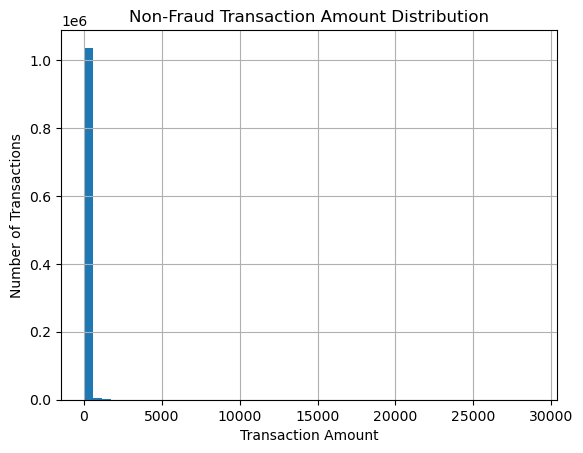

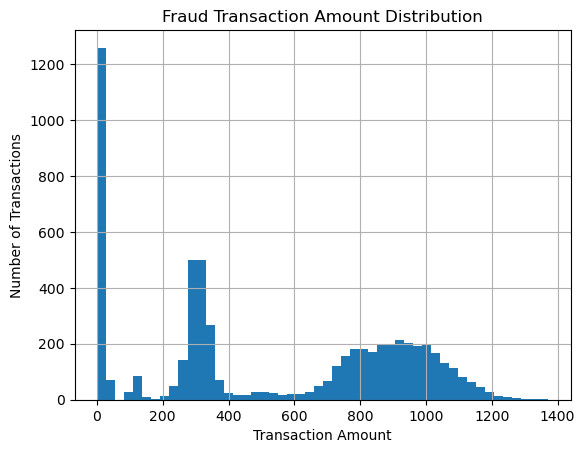

In [8]:
import matplotlib.pyplot as plt

# Non-Fraud Transactions
plt.figure()
df[df['is_fraud']==0]['amt'].hist(bins=50)
plt.title("Non-Fraud Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.show()

# Fraud Transactions
plt.figure()
df[df['is_fraud']==1]['amt'].hist(bins=50)
plt.title("Fraud Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.show()

In [10]:
df.groupby('is_fraud')['amt'].mean()
df.groupby('is_fraud')['amt'].median()

is_fraud
0     47.220
1    391.165
Name: amt, dtype: float64

## Time of day fraud spikes

In [12]:
#Converting time to hours
df['hour'] = (df['unix_time'] // 3600) % 24

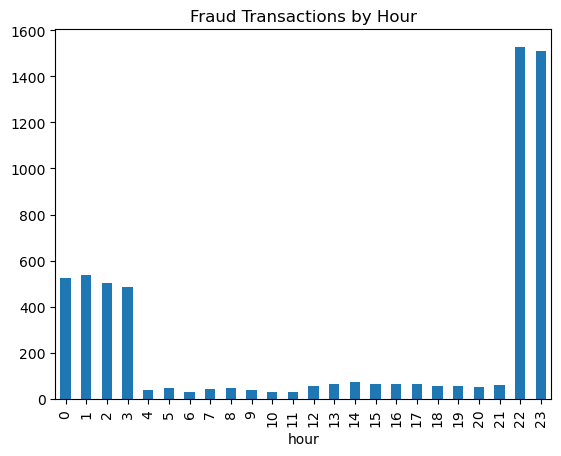

In [13]:
#Bar graph showing when fraud occurs most frequently
fraud_by_hour = df[df['is_fraud']==1]['hour'].value_counts().sort_index()

plt.figure()
fraud_by_hour.plot(kind='bar')
plt.title("Fraud Transactions by Hour")
plt.show()

## Transaction amount anomilies

<Figure size 640x480 with 0 Axes>

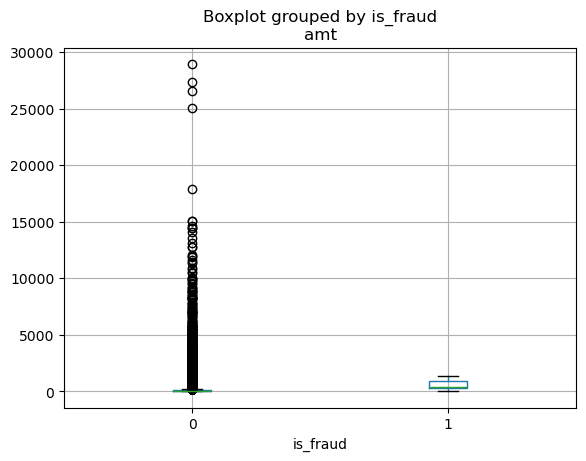

In [15]:
# Showing fraud amount outliers
plt.figure()
df.boxplot(column='amt', by='is_fraud')
plt.show()

## Risk Flags

In [17]:
# Fraud rate for large transactions
df['High_Amount_Flag'] = df['amt'] > df['amt'].quantile(0.95)

df['Night_Transaction_Flag'] = df['hour'].apply(lambda x: 1 if x <= 5 else 0)

In [18]:
pd.crosstab(df['High_Amount_Flag'], df['is_fraud'], normalize='index')

is_fraud,0,1
High_Amount_Flag,,
False,0.99854,0.00146
True,0.91317,0.08683
